In [1]:
import torch
import numpy as np
from tqdm.auto import tqdm
import lovely_tensors as lt
lt.monkey_patch()
import matplotlib.pyplot as plt
import argparse

import os, sys
sys.path.append('/home/ubuntu/repos/normative-diffusion')
os.chdir('/home/ubuntu/repos/normative-diffusion')

from accelerate import Accelerator, DistributedDataParallelKwargs
from sklearn.metrics import average_precision_score
from skimage.filters import threshold_yen
from scipy.ndimage import generate_binary_structure
from diffusion import *
from modules import *
from utils import *



In [2]:

# add manual argparse without any command line arguments
class BraTSArgs:
    dataset_path = 'data/brats'
    path_to_csv = 'data/brats_eval_fig.csv'
    batch_size = 1
    image_size = 128

class ShiftsArgs:
    dataset_path = 'data/shifts_registered/patients'
    path_to_csv = 'data/shifts_eval_fig.csv'
    batch_size = 1
    image_size = 128

bratsargs = BraTSArgs()
shiftsargs = ShiftsArgs()

args = bratsargs # to get brats datapoint

In [3]:
# aggregating all results from all configs
real_slices = {}
real_segmentations = {}
channelwise_maps = {}
anomaly_map = {}
yen_threshold = {}


## ANDi Gaussian -> Gaussian BraTS

In [4]:
torch.manual_seed(73)

args = BraTSArgs()
args.model = 'DDPM-Gauss'

kwargs = DistributedDataParallelKwargs(find_unused_parameters=True)
accelerator = Accelerator(kwargs_handlers=[kwargs])
device = accelerator.device
model = UNet().to(device=device)
print(f"loading {args.model}")
ckpt = torch.load(f"data/brats/models/{args.model}/232_ema_ckpt.pt")

model.load_state_dict(ckpt)
diffusion = Diffusion(noise_steps=1000, img_size=128, device=device)
print("Loading dataset {}...".format(args.dataset_path))
dataloader = MRI_Volume(
    args, hist=False, shift=(True if "shifts" in args.dataset_path else False))

model, dataloader = accelerator.prepare(model, dataloader)
pbar = tqdm(dataloader)

all_images = []
all_volumes = []
all_labels = []


for i, (image, label) in enumerate(pbar):
    image = (image * 2) - 1
    num_steps = 200
    size_splits = 200
    num_volumes = image.shape[0]
    num_slices = image.shape[4]

    all_images.append(image.to("cpu"))
    image = torch.permute(image, (0, 4, 1, 2, 3))
    image = image.view(-1, image.shape[2], image.shape[3], image.shape[4])
    split = torch.split(image, size_splits)
    zs_list = []
    for my_tensor in split:
        zs = diffusion.dpm_differences(
            model, my_tensor, start=75, stop=num_steps, pyramid=False
        ).to("cpu")
        # zs = diffusion.skip_differences(model, my_tensor, start = 100, stop = num_steps, skip=25, pyramid=False).to('cpu')
        # zs = diffusion.differences_noise(model, my_tensor, start = 100, stop = num_steps, pyramid=False).to('cpu')
        zs_list.append(zs)

    zs_list = torch.cat(zs_list, dim=0)
    my_mean = gmean(zs_list, dim=1)
    # my_mean = torch.mean(zs_list,dim=1)

    my_mean = my_mean.view(
        num_volumes,
        num_slices,
        my_mean.shape[1],
        my_mean.shape[2],
        my_mean.shape[3],
    )
    my_mean = torch.permute(my_mean, (0, 2, 3, 4, 1))
    my_mean = my_mean.to(device)
    my_mean, label = accelerator.gather_for_metrics((my_mean, label))
    all_labels.append(label.to("cpu"))
    all_volumes.append(my_mean.to("cpu"))

all_volumes = torch.cat(all_volumes, dim=0)
my_labels = torch.cat(all_labels, dim=0)
all_images = torch.cat(all_images, dim=0)


loading DDPM-Gauss
Loading dataset data/brats...


125it [00:00, 747.07it/s]00<?, ?it/s]
125it [00:25,  4.86it/s]
125it [00:00, 759.15it/s]40<00:40, 40.71s/it]
125it [00:25,  4.98it/s]
100%|██████████| 2/2 [01:13<00:00, 36.87s/it]


In [5]:

# anomaly map postprocessing
my_mask = torch.max(all_volumes, dim=1)[0]
mask_median = torch.clone(my_mask)
mask_median = median_filter_3D(mask_median, kernelsize=5)
mask_median = norm_tensor(mask_median)
big_segmentation = torch.zeros_like(my_mask)

# yen thresholding
for j, volume in enumerate(mask_median):
    thr = threshold_yen(volume.numpy())
    segmentation = torch.where(volume > thr, 1.0, 0.0)
    big_segmentation[j] = segmentation
            
struc = generate_binary_structure(3, 1)
big_segmentation = bin_dilation(big_segmentation, struc) # iterates inside over list of volumes


# compute dice yen
yen_val = []
yen_val.extend([float(x) for x in dice(big_segmentation, my_labels)])
yen_val = np.mean(np.asarray(yen_val))
print('yen dice score: ', yen_val)

Median filtering:   0%|          | 0/2 [00:00<?, ?it/s]

Binray Dilation: 100%|██████████| 2/2 [00:00<00:00, 22.03it/s]

yen dice score:  0.6845665574073792


In [6]:
# aggregating all results for this config
key = 'ANDi_G_G-BraTS'
real_slices[key] = all_images
real_segmentations[key] = all_labels
channelwise_maps[key] = all_volumes
anomaly_map[key] = mask_median
yen_threshold[key] = big_segmentation



## ANDi Pyramidal -> Gaussian BraTS

In [7]:
torch.manual_seed(73)

args = BraTSArgs()
args.model = 'DDPM-Pyramid'

kwargs = DistributedDataParallelKwargs(find_unused_parameters=True)
accelerator = Accelerator(kwargs_handlers=[kwargs])
device = accelerator.device
model = UNet().to(device=device)
print(f"loading {args.model}")
ckpt = torch.load(f"data/brats/models/{args.model}/232_ema_ckpt.pt")

model.load_state_dict(ckpt)
diffusion = Diffusion(noise_steps=1000, img_size=128, device=device)
print("Loading dataset {}...".format(args.dataset_path))
dataloader = MRI_Volume(
    args, hist=False, shift=(True if "shifts" in args.dataset_path else False))

model, dataloader = accelerator.prepare(model, dataloader)
pbar = tqdm(dataloader)

all_images = []
all_volumes = []
all_labels = []


for i, (image, label) in enumerate(pbar):
    image = (image * 2) - 1
    num_steps = 200
    size_splits = 200
    num_volumes = image.shape[0]
    num_slices = image.shape[4]

    all_images.append(image.to("cpu"))
    image = torch.permute(image, (0, 4, 1, 2, 3))
    image = image.view(-1, image.shape[2], image.shape[3], image.shape[4])
    split = torch.split(image, size_splits)
    zs_list = []
    for my_tensor in split:
        zs = diffusion.dpm_differences(
            model, my_tensor, start=75, stop=num_steps, pyramid=False
        ).to("cpu")
        # zs = diffusion.skip_differences(model, my_tensor, start = 100, stop = num_steps, skip=25, pyramid=False).to('cpu')
        # zs = diffusion.differences_noise(model, my_tensor, start = 100, stop = num_steps, pyramid=False).to('cpu')
        zs_list.append(zs)

    zs_list = torch.cat(zs_list, dim=0)
    my_mean = gmean(zs_list, dim=1)
    # my_mean = torch.mean(zs_list,dim=1)

    my_mean = my_mean.view(
        num_volumes,
        num_slices,
        my_mean.shape[1],
        my_mean.shape[2],
        my_mean.shape[3],
    )
    my_mean = torch.permute(my_mean, (0, 2, 3, 4, 1))
    my_mean = my_mean.to(device)
    my_mean, label = accelerator.gather_for_metrics((my_mean, label))
    all_labels.append(label.to("cpu"))
    all_volumes.append(my_mean.to("cpu"))

all_volumes = torch.cat(all_volumes, dim=0)
my_labels = torch.cat(all_labels, dim=0)
all_images = torch.cat(all_images, dim=0)


loading DDPM-Pyramid
Loading dataset data/brats...


125it [00:00, 756.50it/s]00<?, ?it/s]
125it [00:25,  4.95it/s]
125it [00:00, 761.52it/s]38<00:38, 38.74s/it]
125it [00:25,  4.95it/s]
100%|██████████| 2/2 [01:12<00:00, 36.25s/it]


In [8]:

# anomaly map postprocessing
my_mask = torch.max(all_volumes, dim=1)[0]
mask_median = torch.clone(my_mask)
mask_median = median_filter_3D(mask_median, kernelsize=5)
mask_median = norm_tensor(mask_median)
big_segmentation = torch.zeros_like(my_mask)

# yen thresholding
for j, volume in enumerate(mask_median):
    thr = threshold_yen(volume.numpy())
    segmentation = torch.where(volume > thr, 1.0, 0.0)
    big_segmentation[j] = segmentation
            
struc = generate_binary_structure(3, 1)
big_segmentation = bin_dilation(big_segmentation, struc) # iterates inside over list of volumes


# compute dice yen
yen_val = []
yen_val.extend([float(x) for x in dice(big_segmentation, my_labels)])
yen_val = np.mean(np.asarray(yen_val))
print('yen dice score: ', yen_val)

Median filtering:   0%|          | 0/2 [00:00<?, ?it/s]

Binray Dilation: 100%|██████████| 2/2 [00:00<00:00, 22.17it/s]

yen dice score:  0.8699573874473572


In [9]:
# aggregating all results for this config
key = 'ANDi_P_G-BraTS'
real_slices[key] = all_images
real_segmentations[key] = all_labels
channelwise_maps[key] = all_volumes
anomaly_map[key] = mask_median
yen_threshold[key] = big_segmentation



## ANDi Pyramidal -> Pyramidal BraTS

In [10]:
torch.manual_seed(73)

args = BraTSArgs()
args.model = 'DDPM-Pyramid'

kwargs = DistributedDataParallelKwargs(find_unused_parameters=True)
accelerator = Accelerator(kwargs_handlers=[kwargs])
device = accelerator.device
model = UNet().to(device=device)
print(f"loading {args.model}")
ckpt = torch.load(f"data/brats/models/{args.model}/232_ema_ckpt.pt")

model.load_state_dict(ckpt)
diffusion = Diffusion(noise_steps=1000, img_size=128, device=device)
print("Loading dataset {}...".format(args.dataset_path))
dataloader = MRI_Volume(
    args, hist=False, shift=(True if "shifts" in args.dataset_path else False))

model, dataloader = accelerator.prepare(model, dataloader)
pbar = tqdm(dataloader)

all_images = []
all_volumes = []
all_labels = []


for i, (image, label) in enumerate(pbar):
    image = (image * 2) - 1
    num_steps = 200
    size_splits = 200
    num_volumes = image.shape[0]
    num_slices = image.shape[4]

    all_images.append(image.to("cpu"))
    image = torch.permute(image, (0, 4, 1, 2, 3))
    image = image.view(-1, image.shape[2], image.shape[3], image.shape[4])
    split = torch.split(image, size_splits)
    zs_list = []
    for my_tensor in split:
        zs = diffusion.dpm_differences(
            model, my_tensor, start=75, stop=num_steps, pyramid=True
        ).to("cpu")
        # zs = diffusion.skip_differences(model, my_tensor, start = 100, stop = num_steps, skip=25, pyramid=False).to('cpu')
        # zs = diffusion.differences_noise(model, my_tensor, start = 100, stop = num_steps, pyramid=False).to('cpu')
        zs_list.append(zs)

    zs_list = torch.cat(zs_list, dim=0)
    my_mean = gmean(zs_list, dim=1)
    # my_mean = torch.mean(zs_list,dim=1)

    my_mean = my_mean.view(
        num_volumes,
        num_slices,
        my_mean.shape[1],
        my_mean.shape[2],
        my_mean.shape[3],
    )
    my_mean = torch.permute(my_mean, (0, 2, 3, 4, 1))
    my_mean = my_mean.to(device)
    my_mean, label = accelerator.gather_for_metrics((my_mean, label))
    all_labels.append(label.to("cpu"))
    all_volumes.append(my_mean.to("cpu"))

all_volumes = torch.cat(all_volumes, dim=0)
my_labels = torch.cat(all_labels, dim=0)
all_images = torch.cat(all_images, dim=0)


loading DDPM-Pyramid
Loading dataset data/brats...


125it [00:23,  5.41it/s]:00<?, ?it/s]
125it [00:25,  4.97it/s]
125it [00:24,  5.16it/s]:00<01:00, 60.51s/it]
125it [00:25,  4.97it/s]
100%|██████████| 2/2 [01:58<00:00, 59.33s/it]


In [11]:

# anomaly map postprocessing
my_mask = torch.max(all_volumes, dim=1)[0]
mask_median = torch.clone(my_mask)
mask_median = median_filter_3D(mask_median, kernelsize=5)
mask_median = norm_tensor(mask_median)
big_segmentation = torch.zeros_like(my_mask)

# yen thresholding
for j, volume in enumerate(my_mask):
    thr = threshold_yen(volume.numpy())
    segmentation = torch.where(volume > thr, 1.0, 0.0)
    big_segmentation[j] = segmentation
            
struc = generate_binary_structure(3, 1)
big_segmentation = bin_dilation(big_segmentation, struc) # iterates inside over list of volumes

# compute dice yen
yen_val = []
yen_val.extend([float(x) for x in dice(big_segmentation, my_labels)])
yen_val = np.mean(np.asarray(yen_val))
print('yen dice score: ', yen_val)

Median filtering:   0%|          | 0/2 [00:00<?, ?it/s]

Binray Dilation: 100%|██████████| 2/2 [00:00<00:00, 22.23it/s]

yen dice score:  0.5897212624549866


In [12]:
# aggregating all results for this config
key = 'ANDi_P_P-BraTS'
real_slices[key] = all_images
real_segmentations[key] = all_labels
channelwise_maps[key] = all_volumes
anomaly_map[key] = mask_median
yen_threshold[key] = big_segmentation



## ANDi Gauss -> Gauss Shifts

In [10]:
torch.manual_seed(73)

args = ShiftsArgs()
args.model = 'DDPM-Gauss'

kwargs = DistributedDataParallelKwargs(find_unused_parameters=True)
accelerator = Accelerator(kwargs_handlers=[kwargs])
device = accelerator.device
model = UNet().to(device=device)
print(f"loading {args.model}")
ckpt = torch.load(f"data/brats/models/{args.model}/232_ema_ckpt.pt")

model.load_state_dict(ckpt)
diffusion = Diffusion(noise_steps=1000, img_size=128, device=device)
print("Loading dataset {}...".format(args.dataset_path))
dataloader = MRI_Volume(
    args, hist=False, shift=(True if "shifts" in args.dataset_path else False))

model, dataloader = accelerator.prepare(model, dataloader)
pbar = tqdm(dataloader)

all_images = []
all_volumes = []
all_labels = []


for i, (image, label) in enumerate(pbar):
    image = (image * 2) - 1
    num_steps = 200
    size_splits = 200
    num_volumes = image.shape[0]
    num_slices = image.shape[4]

    all_images.append(image.to("cpu"))
    image = torch.permute(image, (0, 4, 1, 2, 3))
    image = image.view(-1, image.shape[2], image.shape[3], image.shape[4])
    split = torch.split(image, size_splits)
    zs_list = []
    for my_tensor in split:
        zs = diffusion.dpm_differences(
            model, my_tensor, start=75, stop=num_steps, pyramid=False
        ).to("cpu")
        # zs = diffusion.skip_differences(model, my_tensor, start = 100, stop = num_steps, skip=25, pyramid=False).to('cpu')
        # zs = diffusion.differences_noise(model, my_tensor, start = 100, stop = num_steps, pyramid=False).to('cpu')
        zs_list.append(zs)

    zs_list = torch.cat(zs_list, dim=0)
    my_mean = gmean(zs_list, dim=1)
    # my_mean = torch.mean(zs_list,dim=1)

    my_mean = my_mean.view(
        num_volumes,
        num_slices,
        my_mean.shape[1],
        my_mean.shape[2],
        my_mean.shape[3],
    )
    my_mean = torch.permute(my_mean, (0, 2, 3, 4, 1))
    my_mean = my_mean.to(device)
    my_mean, label = accelerator.gather_for_metrics((my_mean, label))
    all_labels.append(label.to("cpu"))
    all_volumes.append(my_mean.to("cpu"))

all_volumes = torch.cat(all_volumes, dim=0)
my_labels = torch.cat(all_labels, dim=0)
all_images = torch.cat(all_images, dim=0)


loading DDPM-Gauss
Loading dataset data/shifts_registered/patients...


125it [00:00, 760.10it/s]00<?, ?it/s]
125it [00:25,  4.97it/s]
125it [00:00, 769.27it/s]40<00:40, 40.35s/it]
125it [00:25,  4.97it/s]
100%|██████████| 2/2 [01:13<00:00, 36.90s/it]


In [11]:

# anomaly map postprocessing
my_mask = torch.max(all_volumes, dim=1)[0]
mask_median = torch.clone(my_mask)
mask_median = median_filter_3D(mask_median, kernelsize=5)
mask_median = norm_tensor(mask_median)
big_segmentation = torch.zeros_like(my_mask)

# yen thresholding
for j, volume in enumerate(mask_median):
    thr = threshold_yen(volume.numpy())
    segmentation = torch.where(volume > thr, 1.0, 0.0)
    big_segmentation[j] = segmentation
            
struc = generate_binary_structure(3, 1)
big_segmentation = bin_dilation(big_segmentation, struc) # iterates inside over list of volumes

# compute dice yen
yen_val = []
yen_val.extend([float(x) for x in dice(big_segmentation, my_labels)])
yen_val = np.mean(np.asarray(yen_val))
print('yen dice score: ', yen_val)

Median filtering:   0%|          | 0/2 [00:00<?, ?it/s]

Binray Dilation: 100%|██████████| 2/2 [00:00<00:00, 21.58it/s]


yen dice score:  0.27723752707242966


In [12]:
# aggregating all results for this config
key = 'ANDi_G_G-Shifts'
real_slices[key] = all_images
real_segmentations[key] = all_labels
channelwise_maps[key] = all_volumes
anomaly_map[key] = mask_median
yen_threshold[key] = big_segmentation



## ANDi Pyramidal -> Gauss Shifts

In [13]:
torch.manual_seed(73)

args = ShiftsArgs()
args.model = 'DDPM-Pyramid'

kwargs = DistributedDataParallelKwargs(find_unused_parameters=True)
accelerator = Accelerator(kwargs_handlers=[kwargs])
device = accelerator.device
model = UNet().to(device=device)
print(f"loading {args.model}")
ckpt = torch.load(f"data/brats/models/{args.model}/232_ema_ckpt.pt")

model.load_state_dict(ckpt)
diffusion = Diffusion(noise_steps=1000, img_size=128, device=device)
print("Loading dataset {}...".format(args.dataset_path))
dataloader = MRI_Volume(
    args, hist=False, shift=(True if "shifts" in args.dataset_path else False))

model, dataloader = accelerator.prepare(model, dataloader)
pbar = tqdm(dataloader)

all_images = []
all_volumes = []
all_labels = []


for i, (image, label) in enumerate(pbar):
    image = (image * 2) - 1
    num_steps = 200
    size_splits = 200
    num_volumes = image.shape[0]
    num_slices = image.shape[4]

    all_images.append(image.to("cpu"))
    image = torch.permute(image, (0, 4, 1, 2, 3))
    image = image.view(-1, image.shape[2], image.shape[3], image.shape[4])
    split = torch.split(image, size_splits)
    zs_list = []
    for my_tensor in split:
        zs = diffusion.dpm_differences(
            model, my_tensor, start=75, stop=num_steps, pyramid=False
        ).to("cpu")
        # zs = diffusion.skip_differences(model, my_tensor, start = 100, stop = num_steps, skip=25, pyramid=False).to('cpu')
        # zs = diffusion.differences_noise(model, my_tensor, start = 100, stop = num_steps, pyramid=False).to('cpu')
        zs_list.append(zs)

    zs_list = torch.cat(zs_list, dim=0)
    my_mean = gmean(zs_list, dim=1)
    # my_mean = torch.mean(zs_list,dim=1)

    my_mean = my_mean.view(
        num_volumes,
        num_slices,
        my_mean.shape[1],
        my_mean.shape[2],
        my_mean.shape[3],
    )
    my_mean = torch.permute(my_mean, (0, 2, 3, 4, 1))
    my_mean = my_mean.to(device)
    my_mean, label = accelerator.gather_for_metrics((my_mean, label))
    all_labels.append(label.to("cpu"))
    all_volumes.append(my_mean.to("cpu"))

all_volumes = torch.cat(all_volumes, dim=0)
my_labels = torch.cat(all_labels, dim=0)
all_images = torch.cat(all_images, dim=0)


loading DDPM-Pyramid
Loading dataset data/shifts_registered/patients...


125it [00:00, 763.68it/s]00<?, ?it/s]
125it [00:25,  4.96it/s]
125it [00:00, 747.14it/s]39<00:39, 39.39s/it]
125it [00:25,  4.95it/s]
100%|██████████| 2/2 [01:13<00:00, 36.57s/it]


In [14]:

# anomaly map postprocessing
my_mask = torch.max(all_volumes, dim=1)[0]
mask_median = torch.clone(my_mask)
mask_median = median_filter_3D(mask_median, kernelsize=5)
mask_median = norm_tensor(mask_median)
big_segmentation = torch.zeros_like(my_mask)

# yen thresholding
for j, volume in enumerate(mask_median):
    thr = threshold_yen(volume.numpy())
    segmentation = torch.where(volume > thr, 1.0, 0.0)
    big_segmentation[j] = segmentation
            
struc = generate_binary_structure(3, 1)
big_segmentation = bin_dilation(big_segmentation, struc) # iterates inside over list of volumes

# compute dice yen
yen_val = []
yen_val.extend([float(x) for x in dice(big_segmentation, my_labels)])
yen_val = np.mean(np.asarray(yen_val))
print('yen dice score: ', yen_val)

Median filtering:   0%|          | 0/2 [00:00<?, ?it/s]

Binray Dilation: 100%|██████████| 2/2 [00:00<00:00, 21.88it/s]

yen dice score:  0.6057475060224533


In [15]:
# aggregating all results for this config
key = 'ANDi_P_G-Shifts'
real_slices[key] = all_images
real_segmentations[key] = all_labels
channelwise_maps[key] = all_volumes
anomaly_map[key] = mask_median
yen_threshold[key] = big_segmentation



## ANDi Pyramidal -> Pyramidal Shifts

In [19]:
torch.manual_seed(73)

args = ShiftsArgs()
args.model = 'DDPM-Pyramid'

kwargs = DistributedDataParallelKwargs(find_unused_parameters=True)
accelerator = Accelerator(kwargs_handlers=[kwargs])
device = accelerator.device
model = UNet().to(device=device)
print(f"loading {args.model}")
ckpt = torch.load(f"data/brats/models/{args.model}/232_ema_ckpt.pt")

model.load_state_dict(ckpt)
diffusion = Diffusion(noise_steps=1000, img_size=128, device=device)
print("Loading dataset {}...".format(args.dataset_path))
dataloader = MRI_Volume(
    args, hist=False, shift=(True if "shifts" in args.dataset_path else False))

model, dataloader = accelerator.prepare(model, dataloader)
pbar = tqdm(dataloader)

all_images = []
all_volumes = []
all_labels = []


for i, (image, label) in enumerate(pbar):
    image = (image * 2) - 1
    num_steps = 200
    size_splits = 200
    num_volumes = image.shape[0]
    num_slices = image.shape[4]

    all_images.append(image.to("cpu"))
    image = torch.permute(image, (0, 4, 1, 2, 3))
    image = image.view(-1, image.shape[2], image.shape[3], image.shape[4])
    split = torch.split(image, size_splits)
    zs_list = []
    for my_tensor in split:
        zs = diffusion.dpm_differences(
            model, my_tensor, start=75, stop=num_steps, pyramid=True
        ).to("cpu")
        # zs = diffusion.skip_differences(model, my_tensor, start = 100, stop = num_steps, skip=25, pyramid=False).to('cpu')
        # zs = diffusion.differences_noise(model, my_tensor, start = 100, stop = num_steps, pyramid=False).to('cpu')
        zs_list.append(zs)

    zs_list = torch.cat(zs_list, dim=0)
    my_mean = gmean(zs_list, dim=1)
    # my_mean = torch.mean(zs_list,dim=1)

    my_mean = my_mean.view(
        num_volumes,
        num_slices,
        my_mean.shape[1],
        my_mean.shape[2],
        my_mean.shape[3],
    )
    my_mean = torch.permute(my_mean, (0, 2, 3, 4, 1))
    my_mean = my_mean.to(device)
    my_mean, label = accelerator.gather_for_metrics((my_mean, label))
    all_labels.append(label.to("cpu"))
    all_volumes.append(my_mean.to("cpu"))

all_volumes = torch.cat(all_volumes, dim=0)
my_labels = torch.cat(all_labels, dim=0)
all_images = torch.cat(all_images, dim=0)


loading DDPM-Pyramid
Loading dataset data/shifts_registered/patients...


  0%|          | 0/2 [00:00<?, ?it/s]

125it [00:22,  5.56it/s]
125it [00:25,  4.98it/s]
125it [00:23,  5.34it/s]:01<01:01, 61.11s/it]
125it [00:25,  4.98it/s]
100%|██████████| 2/2 [01:58<00:00, 59.00s/it]


In [20]:

# anomaly map postprocessing
my_mask = torch.max(all_volumes, dim=1)[0]
mask_median = torch.clone(my_mask)
mask_median = median_filter_3D(mask_median, kernelsize=5)
mask_median = norm_tensor(mask_median)
big_segmentation = torch.zeros_like(my_mask)

# yen thresholding
for j, volume in enumerate(my_mask):
    thr = threshold_yen(volume.numpy())
    segmentation = torch.where(volume > thr, 1.0, 0.0)
    big_segmentation[j] = segmentation
            
struc = generate_binary_structure(3, 1)
big_segmentation = bin_dilation(big_segmentation, struc) # iterates inside over list of volumes

# compute dice yen
yen_val = []
yen_val.extend([float(x) for x in dice(big_segmentation, my_labels)])
yen_val = np.mean(np.asarray(yen_val))
print('yen dice score: ', yen_val)

Binray Dilation: 100%|██████████| 2/2 [00:00<00:00, 22.14it/s]

yen dice score:  0.35996221750974655


In [21]:
# aggregating all results for this config
key = 'ANDi_P_P-Shifts'
real_slices[key] = all_images
real_segmentations[key] = all_labels
channelwise_maps[key] = all_volumes
anomaly_map[key] = mask_median
yen_threshold[key] = big_segmentation



## Thresholding BraTS

In [168]:

from sklearn.metrics import average_precision_score
from skimage.filters import threshold_yen

In [184]:
torch.manual_seed(73)

args = BraTSArgs()
dataloader = MRI_Volume(args, hist=False, shift=(True if "shifts" in args.dataset_path else False))

pbar = tqdm(dataloader)

all_images = []
all_volumes = []
all_labels = []
all_best_dices = []


for i, (image, label) in enumerate(pbar):
    all_labels.append(label.to("cpu"))
    all_volumes.append(image[:,:1].to("cpu"))
    all_images.append(image.to("cpu"))


all_volumes = torch.cat(all_volumes, dim=0)
my_labels = torch.cat(all_labels, dim=0)
all_images = torch.cat(all_images, dim=0)



  0%|          | 0/2 [00:00<?, ?it/s]

100%|██████████| 2/2 [00:05<00:00,  2.98s/it]


In [185]:
all_volumes

tensor[2, 1, 128, 128, 155] n=5079040 x∈[0., 1.533] μ=0.084 σ=0.201

In [186]:

# anomaly map postprocessing
my_mask = torch.max(all_volumes, dim=1)[0]
mask_median = torch.clone(my_mask)
mask_median = median_filter_3D(mask_median, kernelsize=5)
mask_median = norm_tensor(mask_median)
big_segmentation = torch.zeros_like(my_mask)

# yen thresholding
for j, volume in enumerate(mask_median):
    thr = threshold_yen(volume.numpy())
    segmentation = torch.where(volume > thr, 1.0, 0.0)
    big_segmentation[j] = segmentation
            
struc = generate_binary_structure(3, 1)
big_segmentation = bin_dilation(big_segmentation, struc) # iterates inside over list of volumes

# compute dice yen
yen_val = []
yen_val.extend([float(x) for x in dice(big_segmentation, my_labels)])
yen_val = np.mean(np.asarray(yen_val))
print('yen dice score: ', yen_val)

Median filtering:   0%|          | 0/2 [00:00<?, ?it/s]

Binray Dilation: 100%|██████████| 2/2 [00:00<00:00, 19.97it/s]

yen dice score:  0.47946926206350327


In [191]:
# aggregating all results for this config
key = 'Thresholding-BraTS'
real_slices[key] = all_images
real_segmentations[key] = all_labels
channelwise_maps[key] = all_volumes
anomaly_map[key] = mask_median
yen_threshold[key] = big_segmentation



## Thresholding Shifts

In [198]:
torch.manual_seed(73)

args = ShiftsArgs()
dataloader = MRI_Volume(args, hist=False, shift=(True if "shifts" in args.dataset_path else False))

pbar = tqdm(dataloader)

all_images = []
all_volumes = []
all_labels = []
all_best_dices = []


for i, (image, label) in enumerate(pbar):
    all_labels.append(label.to("cpu"))
    all_volumes.append(image[:,:1].to("cpu"))
    all_images.append(image.to("cpu"))


all_volumes = torch.cat(all_volumes, dim=0)
my_labels = torch.cat(all_labels, dim=0)
all_images = torch.cat(all_images, dim=0)



100%|██████████| 2/2 [00:08<00:00,  4.08s/it]


In [199]:

# anomaly map postprocessing
my_mask = torch.max(all_volumes, dim=1)[0]
mask_median = torch.clone(my_mask)
mask_median = median_filter_3D(mask_median, kernelsize=5)
mask_median = norm_tensor(mask_median)
big_segmentation = torch.zeros_like(my_mask)

# yen thresholding
for j, volume in enumerate(mask_median):
    thr = threshold_yen(volume.numpy())
    segmentation = torch.where(volume > thr, 1.0, 0.0)
    big_segmentation[j] = segmentation
            
struc = generate_binary_structure(3, 1)
big_segmentation = bin_dilation(big_segmentation, struc) # iterates inside over list of volumes

# compute dice yen
yen_val = []
yen_val.extend([float(x) for x in dice(big_segmentation, my_labels)])
yen_val = np.mean(np.asarray(yen_val))
print('yen dice score: ', yen_val)

Binray Dilation: 100%|██████████| 2/2 [00:00<00:00, 20.50it/s]


yen dice score:  0.028832677751779556


In [201]:
# aggregating all results for this config
key = 'Thresholding-Shifts'
real_slices[key] = all_images
real_segmentations[key] = all_labels
channelwise_maps[key] = all_volumes
anomaly_map[key] = mask_median
yen_threshold[key] = big_segmentation



In [188]:
anomaly_map

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)

In [192]:
channelwise_maps

{'ANDi_G_G-BraTS': tensor[2, 4, 128, 128, 155] n=20316160 x∈[0., 0.000] μ=3.337e-07 σ=2.239e-06,
 'ANDi_P_G-BraTS': tensor[2, 4, 128, 128, 155] n=20316160 x∈[0., 0.000] μ=1.705e-06 σ=3.809e-06,
 'ANDi_G_G-Shifts': tensor[2, 4, 128, 128, 155] n=20316160 x∈[0., 0.000] μ=4.163e-07 σ=2.100e-06,
 'ANDi_P_G-Shifts': tensor[2, 4, 128, 128, 155] n=20316160 x∈[0., 0.000] μ=1.902e-06 σ=2.688e-06,
 'AnoDDPM-Brats': tensor[2, 4, 128, 128, 155] n=20316160 x∈[8.882e-16, 3.010] μ=0.010 σ=0.041,
 'AnoDDPM-Shifts': tensor[2, 4, 128, 128, 155] n=20316160 x∈[0., 2.969] μ=0.011 σ=0.042,
 'AutoDDPM-BraTS': tensor[2, 4, 128, 128, 155] n=20316160 x∈[0., 0.860] μ=0.000 σ=0.007,
 'AutoDDPM-Shifts': tensor[2, 4, 128, 128, 155] n=20316160 x∈[0., 0.740] μ=0.000 σ=0.006,
 'DAE-BraTS': tensor[2, 4, 128, 128, 155] n=20316160 x∈[0., 0.555] μ=0.005 σ=0.018,
 'DAE-Shifts': tensor[2, 4, 128, 128, 155] n=20316160 x∈[0., 0.524] μ=0.009 σ=0.026,
 'AnoDDPM-BraTS': tensor[2, 4, 128, 128, 155] n=20316160 x∈[8.882e-16, 3.010] 

In [193]:
anomaly_map = {}
yen_threshold = {}
# recomputing anomaly_map[key] and yen_threshold[key] for all
for key in real_slices:
    all_volumes = channelwise_maps[key]
    # anomaly map postprocessing
    my_mask = torch.max(all_volumes, dim=1)[0]
    mask_median = torch.clone(my_mask)
    mask_median = median_filter_3D(mask_median, kernelsize=5)
    mask_median = norm_tensor(mask_median)
    big_segmentation = torch.zeros_like(my_mask)

    # yen thresholding
    for j, volume in enumerate(mask_median):
        thr = threshold_yen(volume.numpy())
        segmentation = torch.where(volume > thr, 1.0, 0.0)
        big_segmentation[j] = segmentation
                
    struc = generate_binary_structure(3, 1)
    big_segmentation = bin_dilation(big_segmentation, struc) # iterates inside over list of volumes

    # compute dice yen
    yen_val = []
    yen_val.extend([float(x) for x in dice(big_segmentation, my_labels)])
    yen_val = np.mean(np.asarray(yen_val))
    print('yen dice score: ', yen_val, 'for key' + key)

    anomaly_map[key] = mask_median
    yen_threshold[key] = big_segmentation

Binray Dilation: 100%|██████████| 2/2 [00:00<00:00, 17.89it/s]


yen dice score:  0.6845665574073792 for keyANDi_G_G-BraTS


Binray Dilation: 100%|██████████| 2/2 [00:00<00:00, 18.61it/s]


yen dice score:  0.8699573874473572 for keyANDi_P_G-BraTS


Binray Dilation: 100%|██████████| 2/2 [00:00<00:00, 19.06it/s]


...

yen dice score:  0.03599173203110695 for keyDAE-Shifts


Binray Dilation: 100%|██████████| 2/2 [00:00<00:00, 22.20it/s]


yen dice score:  0.7618915438652039 for keyAnoDDPM-BraTS


Binray Dilation: 100%|██████████| 2/2 [00:00<00:00, 22.44it/s]

yen dice score:  0.47946926206350327 for keyThresholding-BraTS


In [194]:
# pickle all global variables
import pickle

with open('data/eval_fig.pkl', 'wb') as f:
    pickle.dump([real_slices, real_segmentations, channelwise_maps, anomaly_map, yen_threshold], f)


## DAE BraTS

In [189]:
import pickle
with open('data/eval_fig.pkl', 'rb') as f:
    real_slices, real_segmentations, channelwise_maps, anomaly_map, yen_threshold = pickle.load(f)

In [178]:
real_slices, real_segmentations, channelwise_maps, anomaly_map, yen_threshold

({'ANDi_G_G-BraTS': tensor[2, 4, 128, 128, 155] n=20316160 x∈[-1.000, 3.197] μ=-0.837 σ=0.399,
  'ANDi_P_G-BraTS': tensor[2, 4, 128, 128, 155] n=20316160 x∈[-1.000, 3.197] μ=-0.837 σ=0.399,
  'ANDi_G_G-Shifts': tensor[2, 4, 128, 128, 155] n=20316160 x∈[-1.000, 5.739] μ=-0.792 σ=0.495,
  'ANDi_P_G-Shifts': tensor[2, 4, 128, 128, 155] n=20316160 x∈[-1.000, 5.739] μ=-0.792 σ=0.495,
  'AnoDDPM-Brats': tensor[2, 4, 128, 128, 155] n=20316160 x∈[-1.000, 3.197] μ=-0.837 σ=0.399,
  'AnoDDPM-Shifts': tensor[2, 4, 128, 128, 155] n=20316160 x∈[-1.000, 5.739] μ=-0.792 σ=0.495,
  'AutoDDPM-BraTS': tensor[2, 4, 128, 128, 155] n=20316160 x∈[-1.000, 3.197] μ=-0.837 σ=0.399,
  'AutoDDPM-Shifts': tensor[2, 4, 128, 128, 155] n=20316160 x∈[-1.000, 5.739] μ=-0.792 σ=0.495,
  'DAE-BraTS': tensor[2, 4, 128, 128, 155] n=20316160 x∈[0., 2.099] μ=0.082 σ=0.199,
  'DAE-Shifts': tensor[2, 4, 128, 128, 155] n=20316160 x∈[0., 3.370] μ=0.104 σ=0.247,
  'AnoDDPM-BraTS': tensor[2, 4, 128, 128, 155] n=20316160 x∈[-1.000

In [132]:
torch.manual_seed(73)

args = BraTSArgs()
args.model = 'DAE'

kwargs = DistributedDataParallelKwargs(find_unused_parameters=True)
accelerator = Accelerator(kwargs_handlers=[kwargs])
device = accelerator.device

from baselines.dae_unet import UNet as DAE_UNet

model = DAE_UNet(4, 4, depth=4, wf=6, padding=True)
print(f"loading {args.model}")
ckpt = torch.load(f"data/brats/models/DAE/2_ckpt.pt")
model.load_state_dict(ckpt)
print("Loading dataset {}...".format(args.dataset_path))
dataloader = MRI_Volume(
    args, hist=False, shift=(True if "shifts" in args.dataset_path else False))

model, dataloader = accelerator.prepare(model, dataloader)
# print number of parameters
num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print('number of parameters: ', num_params)
pbar = tqdm(dataloader)

all_images = []
all_volumes = []
all_labels = []


for i, (image, label) in enumerate(pbar):
    # image = (image * 2) - 1
    num_steps = 200
    size_splits = 200
    num_volumes = image.shape[0]
    num_slices = image.shape[4]

    all_images.append(image.to("cpu"))
    image = torch.permute(image, (0, 4, 1, 2, 3))
    image = image.view(-1, image.shape[2], image.shape[3], image.shape[4])
    split = torch.split(image, size_splits)
    prediction = []
    for my_tensor in split:
        with torch.no_grad():
            pseudo_img = model(my_tensor)
        # Erode the mask a bit to remove some of the reconstruction errors at the edges.
        mask = my_tensor.sum(dim=1, keepdim=True) > 0.01
        mask = (
            F.avg_pool2d(mask.float(), kernel_size=5, stride=1, padding=2)
            > 0.95
        )
        my_diff = ((my_tensor - pseudo_img) * mask).abs()
        prediction.append(my_diff.to("cpu"))

    prediction = torch.cat(prediction, dim=0)
    prediction = prediction.view(
        num_volumes,
        num_slices,
        prediction.shape[1],
        prediction.shape[2],
        prediction.shape[3],
    )
    prediction = torch.permute(prediction, (0, 2, 3, 4, 1))
    prediction = prediction.to(device)
    prediction, label = accelerator.gather_for_metrics((prediction, label))
    all_labels.append(label.to("cpu"))
    all_volumes.append(prediction.to("cpu"))

all_volumes = torch.cat(all_volumes, dim=0)
my_labels = torch.cat(all_labels, dim=0)
all_images = torch.cat(all_images, dim=0)


loading DAE
Loading dataset data/brats...
number of parameters:  7703748


100%|██████████| 2/2 [00:06<00:00,  3.02s/it]


In [133]:

# anomaly map postprocessing
my_mask = torch.max(all_volumes, dim=1)[0]
mask_median = torch.clone(my_mask)
mask_median = median_filter_3D(mask_median, kernelsize=5)
mask_median = norm_tensor(mask_median)
my_mask = norm_tensor(my_mask)
big_segmentation = torch.zeros_like(my_mask)

# # yen thresholding
# for j, volume in enumerate(my_mask):
#     thr = threshold_yen(volume.numpy())
#     segmentation = torch.where(volume > thr, 1.0, 0.0)
#     big_segmentation[j] = segmentation
            
# struc = generate_binary_structure(3, 1)
# big_segmentation = bin_dilation(big_segmentation, struc) # iterates inside over list of volumes

# # compute dice yen
# yen_val = []
# yen_val.extend([float(x) for x in dice(big_segmentation, my_labels)])
# yen_val = np.mean(np.asarray(yen_val))
# print('yen dice score: ', yen_val)

# yen thresholding
for j, volume in enumerate(mask_median):
    thr = threshold_yen(volume.numpy())
    segmentation = torch.where(volume > thr, 1.0, 0.0)
    big_segmentation[j] = segmentation
            
struc = generate_binary_structure(3, 1)
big_segmentation = bin_dilation(big_segmentation, struc) # iterates inside over list of volumes

# compute dice yen
yen_val = []
yen_val.extend([float(x) for x in dice(big_segmentation, my_labels)])
yen_val = np.mean(np.asarray(yen_val))
print('yen dice score mf: ', yen_val)

Median filtering:   0%|          | 0/2 [00:00<?, ?it/s]

Binray Dilation: 100%|██████████| 2/2 [00:00<00:00, 20.61it/s]

yen dice score mf:  0.8055786490440369


In [134]:
mask_median

tensor[2, 128, 128, 155] n=5079040 x∈[0., 1.000] μ=0.018 σ=0.057

In [135]:
# aggregating all results for this config
key = 'DAE-BraTS'
real_slices[key] = all_images
real_segmentations[key] = all_labels
channelwise_maps[key] = all_volumes
anomaly_map[key] = mask_median
yen_threshold[key] = big_segmentation



## DAE Shifts

In [136]:
torch.manual_seed(73)

args = ShiftsArgs()
args.model = 'DAE'

kwargs = DistributedDataParallelKwargs(find_unused_parameters=True)
accelerator = Accelerator(kwargs_handlers=[kwargs])
device = accelerator.device

from baselines.dae_unet import UNet as DAE_UNet

model = DAE_UNet(4, 4, depth=4, wf=6, padding=True)
print(f"loading {args.model}")
ckpt = torch.load(f"data/brats/models/DAE/2_ckpt.pt")
model.load_state_dict(ckpt)
print("Loading dataset {}...".format(args.dataset_path))
dataloader = MRI_Volume(
    args, hist=False, shift=(True if "shifts" in args.dataset_path else False))

model, dataloader = accelerator.prepare(model, dataloader)
# print number of parameters
num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print('number of parameters: ', num_params)
pbar = tqdm(dataloader)

all_images = []
all_volumes = []
all_labels = []


for i, (image, label) in enumerate(pbar):
    # image = (image * 2) - 1
    num_steps = 200
    size_splits = 200
    num_volumes = image.shape[0]
    num_slices = image.shape[4]

    all_images.append(image.to("cpu"))
    image = torch.permute(image, (0, 4, 1, 2, 3))
    image = image.view(-1, image.shape[2], image.shape[3], image.shape[4])
    split = torch.split(image, size_splits)
    prediction = []
    for my_tensor in split:
        with torch.no_grad():
            pseudo_img = model(my_tensor)
        # Erode the mask a bit to remove some of the reconstruction errors at the edges.
        mask = my_tensor.sum(dim=1, keepdim=True) > 0.01
        mask = (
            F.avg_pool2d(mask.float(), kernel_size=5, stride=1, padding=2)
            > 0.95
        )
        my_diff = ((my_tensor - pseudo_img) * mask).abs()
        prediction.append(my_diff.to("cpu"))

    prediction = torch.cat(prediction, dim=0)
    prediction = prediction.view(
        num_volumes,
        num_slices,
        prediction.shape[1],
        prediction.shape[2],
        prediction.shape[3],
    )
    prediction = torch.permute(prediction, (0, 2, 3, 4, 1))
    prediction = prediction.to(device)
    prediction, label = accelerator.gather_for_metrics((prediction, label))
    all_labels.append(label.to("cpu"))
    all_volumes.append(prediction.to("cpu"))

all_volumes = torch.cat(all_volumes, dim=0)
my_labels = torch.cat(all_labels, dim=0)
all_images = torch.cat(all_images, dim=0)


loading DAE
Loading dataset data/shifts_registered/patients...
number of parameters:  7703748


100%|██████████| 2/2 [00:08<00:00,  4.24s/it]


In [137]:

# anomaly map postprocessing
my_mask = torch.max(all_volumes, dim=1)[0]
mask_median = torch.clone(my_mask)
mask_median = median_filter_3D(mask_median, kernelsize=5)
mask_median = norm_tensor(mask_median)
my_mask = norm_tensor(my_mask)
big_segmentation = torch.zeros_like(my_mask)

# # yen thresholding
# for j, volume in enumerate(my_mask):
#     thr = threshold_yen(volume.numpy())
#     segmentation = torch.where(volume > thr, 1.0, 0.0)
#     big_segmentation[j] = segmentation
            
# struc = generate_binary_structure(3, 1)
# big_segmentation = bin_dilation(big_segmentation, struc) # iterates inside over list of volumes

# # compute dice yen
# yen_val = []
# yen_val.extend([float(x) for x in dice(big_segmentation, my_labels)])
# yen_val = np.mean(np.asarray(yen_val))
# print('yen dice score: ', yen_val)

# yen thresholding
for j, volume in enumerate(mask_median):
    thr = threshold_yen(volume.numpy())
    segmentation = torch.where(volume > thr, 1.0, 0.0)
    big_segmentation[j] = segmentation
            
struc = generate_binary_structure(3, 1)
big_segmentation = bin_dilation(big_segmentation, struc) # iterates inside over list of volumes

# compute dice yen
yen_val = []
yen_val.extend([float(x) for x in dice(big_segmentation, my_labels)])
yen_val = np.mean(np.asarray(yen_val))
print('yen dice score mf: ', yen_val)

Median filtering: 100%|██████████| 2/2 [00:02<00:00,  1.13s/it]
/mnt/miniconda3/envs/ldm/lib/python3.9/site-packages/skimage/filters/thresholding.py:440: RuntimeWarning: divide by zero encountered in log
  crit = np.log(((P1_sq[:-1] * P2_sq[1:]) ** -1) *
Binray Dilation: 100%|██████████| 2/2 [00:00<00:00, 22.54it/s]

yen dice score mf:  0.329779333434999


In [138]:
# aggregating all results for this config
key = 'DAE-Shifts'
real_slices[key] = all_images
real_segmentations[key] = all_labels
channelwise_maps[key] = all_volumes
anomaly_map[key] = mask_median
yen_threshold[key] = big_segmentation



In [139]:
real_slices

{'ANDi_G_G-BraTS': tensor[2, 4, 128, 128, 155] n=20316160 x∈[-1.000, 3.197] μ=-0.837 σ=0.399,
 'ANDi_P_G-BraTS': tensor[2, 4, 128, 128, 155] n=20316160 x∈[-1.000, 3.197] μ=-0.837 σ=0.399,
 'ANDi_G_G-Shifts': tensor[2, 4, 128, 128, 155] n=20316160 x∈[-1.000, 5.739] μ=-0.792 σ=0.495,
 'ANDi_P_G-Shifts': tensor[2, 4, 128, 128, 155] n=20316160 x∈[-1.000, 5.739] μ=-0.792 σ=0.495,
 'AnoDDPM-Brats': tensor[2, 4, 128, 128, 155] n=20316160 x∈[-1.000, 3.197] μ=-0.837 σ=0.399,
 'AnoDDPM-Shifts': tensor[2, 4, 128, 128, 155] n=20316160 x∈[-1.000, 5.739] μ=-0.792 σ=0.495,
 'AutoDDPM-BraTS': tensor[2, 4, 128, 128, 155] n=20316160 x∈[-1.000, 3.197] μ=-0.837 σ=0.399,
 'AutoDDPM-Shifts': tensor[2, 4, 128, 128, 155] n=20316160 x∈[-1.000, 5.739] μ=-0.792 σ=0.495,
 'DAE-BraTS': tensor[2, 4, 128, 128, 155] n=20316160 x∈[0., 2.099] μ=0.082 σ=0.199,
 'DAE-Shifts': tensor[2, 4, 128, 128, 155] n=20316160 x∈[0., 3.370] μ=0.104 σ=0.247}

In [140]:
with open('data/eval_fig.pkl', 'wb') as f:
    pickle.dump([real_slices, real_segmentations, channelwise_maps, anomaly_map, yen_threshold], f)

## AutoDDPM Brats

In [50]:
import lpips
from baselines.eval_autoddpm import lpips_loss, inpainting_loop, dilate_masks

In [51]:
torch.manual_seed(73)

args = BraTSArgs()
args.model = 'AutoDDPM'

kwargs = DistributedDataParallelKwargs(find_unused_parameters=True)
accelerator = Accelerator(kwargs_handlers=[kwargs])
device = accelerator.device
model = UNet().to(device)
print(f"loading {args.model}")
ckpt = torch.load(f"data/brats/models/DDPM-Gauss/232_ema_ckpt.pt")
model.load_state_dict(ckpt)
diffusion = Diffusion(noise_steps=1000, img_size=128, device=device)
print("Loading dataset {}...".format(args.dataset_path))
dataloader = MRI_Volume(
    args, hist=False, shift=(True if "shifts" in args.dataset_path else False))

model, dataloader = accelerator.prepare(model, dataloader)
pbar = tqdm(dataloader)

my_lpips = lpips.LPIPS(pretrained=True, net='squeeze', use_dropout=True, eval_mode=True, spatial=True, lpips=True).to(device)

all_images = []
all_volumes = []
all_labels = []


for i, (image, label) in enumerate(pbar):
    image = (image * 2) - 1
    num_steps = 200
    size_splits = 200
    num_inpainting = 50
    masking_threshold = 0.124
    resample_steps = 5
    num_volumes = image.shape[0]
    num_slices = image.shape[4]

    all_images.append(image.to("cpu"))
    image = torch.permute(image, (0, 4, 1, 2, 3))
    image = image.view(-1, image.shape[2], image.shape[3], image.shape[4])
    split = torch.split(image, size_splits)
    prediction = []
    with torch.no_grad():
        for my_tensor in split:
            pseudo_healthy = diffusion.ano_ddpm(model, my_tensor, num_steps)
            pseudo_healthy.clamp(-1,1)
            residual = (my_tensor - pseudo_healthy).abs()

            #Steps for first mask
            tripple_health = torch.zeros((my_tensor.shape[0],my_tensor.shape[1],3,my_tensor.shape[2],my_tensor.shape[3])).to(device)
            tripple_pseudo = torch.zeros((my_tensor.shape[0],my_tensor.shape[1],3,my_tensor.shape[2],my_tensor.shape[3])).to(device)
            for k in range(3):
                tripple_health[:,:,k] = my_tensor
                tripple_pseudo[:,:,k] = pseudo_healthy
            my_lpips_mask = torch.zeros_like(my_tensor).to(device)
            for k in range(my_tensor.shape[1]):
                lpips_mask = lpips_loss(my_lpips,tripple_health[:,k], tripple_pseudo[:,k], retPerLayer=False)
                my_lpips_mask[:,k] = lpips_mask[:,0]

            # calculate quantile for each image and modality individually
            my_quantile = torch.zeros_like(residual).to(device)
            for k in range(my_quantile.shape[0]):
                for n in range(my_quantile.shape[1]):
                    my_quantile[k,n] = torch.quantile(residual[k,n],0.99)
            
            residual = (residual/my_quantile).clamp(0,1)
            first_mask = my_lpips_mask * residual
            my_mask = torch.where(first_mask > masking_threshold, torch.ones_like(first_mask), torch.zeros_like(first_mask))
            my_mask = dilate_masks(my_mask)


            image_masked = (1 - my_mask) * my_tensor

            x_inpaint = inpainting_loop(model,diffusion,device,image_masked,pseudo_healthy,my_mask,num_inpainting,resample_steps)
            residual = (my_tensor - x_inpaint.clamp(-1,1)).abs()

            anomaly_score = residual * first_mask
            anomaly_score = anomaly_score.to('cpu')
            prediction.append(anomaly_score)

    prediction = torch.cat(prediction, dim=0)
    prediction = prediction.view(
        num_volumes,
        num_slices,
        prediction.shape[1],
        prediction.shape[2],
        prediction.shape[3],
    )
    prediction = torch.permute(prediction, (0, 2, 3, 4, 1))
    prediction = prediction.to(device)
    prediction, label = accelerator.gather_for_metrics((prediction, label))
    all_labels.append(label.to("cpu"))
    all_volumes.append(prediction.to("cpu"))

all_volumes = torch.cat(all_volumes, dim=0)
my_labels = torch.cat(all_labels, dim=0)
all_images = torch.cat(all_images, dim=0)


loading AutoDDPM
Loading dataset data/brats...


  0%|          | 0/2 [00:00<?, ?it/s]

Setting up [LPIPS] perceptual loss: trunk [squeeze], v[0.1], spatial [on]
Loading model from: /mnt/miniconda3/envs/ldm/lib/python3.9/site-packages/lpips/weights/v0.1/squeeze.pth


/mnt/miniconda3/envs/ldm/lib/python3.9/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/mnt/miniconda3/envs/ldm/lib/python3.9/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=SqueezeNet1_1_Weights.IMAGENET1K_V1`. You can also use `weights=SqueezeNet1_1_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
199it [00:40,  4.97it/s]
49it [00:48,  1.01it/s]
199it [00:40,  4.96it/s]:35<01:35, 95.19s/it]
49it [00:48,  1.01it/s]
100%|██████████| 2/2 [03:05<00:00, 92.55s/it]


In [52]:

# anomaly map postprocessing
my_mask = torch.max(all_volumes, dim=1)[0]
mask_median = torch.clone(my_mask)
mask_median = median_filter_3D(mask_median, kernelsize=5)
mask_median = norm_tensor(mask_median)
my_mask = norm_tensor(my_mask)
big_segmentation = torch.zeros_like(my_mask)

# yen thresholding
for j, volume in enumerate(my_mask):
    thr = threshold_yen(volume.numpy())
    segmentation = torch.where(volume > thr, 1.0, 0.0)
    big_segmentation[j] = segmentation
            
struc = generate_binary_structure(3, 1)
big_segmentation = bin_dilation(big_segmentation, struc) # iterates inside over list of volumes

# compute dice yen
yen_val = []
yen_val.extend([float(x) for x in dice(big_segmentation, my_labels)])
yen_val = np.mean(np.asarray(yen_val))
print('yen dice score: ', yen_val)

# yen thresholding
for j, volume in enumerate(mask_median):
    thr = threshold_yen(volume.numpy())
    segmentation = torch.where(volume > thr, 1.0, 0.0)
    big_segmentation[j] = segmentation
            
struc = generate_binary_structure(3, 1)
big_segmentation = bin_dilation(big_segmentation, struc) # iterates inside over list of volumes

# compute dice yen
yen_val = []
yen_val.extend([float(x) for x in dice(big_segmentation, my_labels)])
yen_val = np.mean(np.asarray(yen_val))
print('yen dice score mf: ', yen_val)

Median filtering: 100%|██████████| 2/2 [00:01<00:00,  1.39it/s]
/mnt/miniconda3/envs/ldm/lib/python3.9/site-packages/skimage/filters/thresholding.py:440: RuntimeWarning: divide by zero encountered in log
  crit = np.log(((P1_sq[:-1] * P2_sq[1:]) ** -1) *
Binray Dilation: 100%|██████████| 2/2 [00:00<00:00, 22.02it/s]


yen dice score:  0.4117029756307602


Binray Dilation: 100%|██████████| 2/2 [00:00<00:00, 22.41it/s]

yen dice score mf:  0.7077147662639618


In [53]:
# aggregating all results for this config
key = 'AutoDDPM-BraTS'
real_slices[key] = all_images
real_segmentations[key] = all_labels
channelwise_maps[key] = all_volumes
anomaly_map[key] = mask_median
yen_threshold[key] = big_segmentation



In [54]:
torch.manual_seed(73)

args = ShiftsArgs()
args.model = 'AutoDDPM'

kwargs = DistributedDataParallelKwargs(find_unused_parameters=True)
accelerator = Accelerator(kwargs_handlers=[kwargs])
device = accelerator.device
model = UNet().to(device)
print(f"loading {args.model}")
ckpt = torch.load(f"data/brats/models/DDPM-Gauss/232_ema_ckpt.pt")
model.load_state_dict(ckpt)
diffusion = Diffusion(noise_steps=1000, img_size=128, device=device)
print("Loading dataset {}...".format(args.dataset_path))
dataloader = MRI_Volume(
    args, hist=False, shift=(True if "shifts" in args.dataset_path else False))

model, dataloader = accelerator.prepare(model, dataloader)
pbar = tqdm(dataloader)

my_lpips = lpips.LPIPS(pretrained=True, net='squeeze', use_dropout=True, eval_mode=True, spatial=True, lpips=True).to(device)

all_images = []
all_volumes = []
all_labels = []


for i, (image, label) in enumerate(pbar):
    image = (image * 2) - 1
    num_steps = 200
    size_splits = 200
    num_inpainting = 50
    masking_threshold = 0.124
    resample_steps = 5
    num_volumes = image.shape[0]
    num_slices = image.shape[4]

    all_images.append(image.to("cpu"))
    image = torch.permute(image, (0, 4, 1, 2, 3))
    image = image.view(-1, image.shape[2], image.shape[3], image.shape[4])
    split = torch.split(image, size_splits)
    prediction = []
    with torch.no_grad():
        for my_tensor in split:
            pseudo_healthy = diffusion.ano_ddpm(model, my_tensor, num_steps)
            pseudo_healthy.clamp(-1,1)
            residual = (my_tensor - pseudo_healthy).abs()

            #Steps for first mask
            tripple_health = torch.zeros((my_tensor.shape[0],my_tensor.shape[1],3,my_tensor.shape[2],my_tensor.shape[3])).to(device)
            tripple_pseudo = torch.zeros((my_tensor.shape[0],my_tensor.shape[1],3,my_tensor.shape[2],my_tensor.shape[3])).to(device)
            for k in range(3):
                tripple_health[:,:,k] = my_tensor
                tripple_pseudo[:,:,k] = pseudo_healthy
            my_lpips_mask = torch.zeros_like(my_tensor).to(device)
            for k in range(my_tensor.shape[1]):
                lpips_mask = lpips_loss(my_lpips,tripple_health[:,k], tripple_pseudo[:,k], retPerLayer=False)
                my_lpips_mask[:,k] = lpips_mask[:,0]

            # calculate quantile for each image and modality individually
            my_quantile = torch.zeros_like(residual).to(device)
            for k in range(my_quantile.shape[0]):
                for n in range(my_quantile.shape[1]):
                    my_quantile[k,n] = torch.quantile(residual[k,n],0.99)
            
            residual = (residual/my_quantile).clamp(0,1)
            first_mask = my_lpips_mask * residual
            my_mask = torch.where(first_mask > masking_threshold, torch.ones_like(first_mask), torch.zeros_like(first_mask))
            my_mask = dilate_masks(my_mask)


            image_masked = (1 - my_mask) * my_tensor

            x_inpaint = inpainting_loop(model,diffusion,device,image_masked,pseudo_healthy,my_mask,num_inpainting,resample_steps)
            residual = (my_tensor - x_inpaint.clamp(-1,1)).abs()

            anomaly_score = residual * first_mask
            anomaly_score = anomaly_score.to('cpu')
            prediction.append(anomaly_score)

    prediction = torch.cat(prediction, dim=0)
    prediction = prediction.view(
        num_volumes,
        num_slices,
        prediction.shape[1],
        prediction.shape[2],
        prediction.shape[3],
    )
    prediction = torch.permute(prediction, (0, 2, 3, 4, 1))
    prediction = prediction.to(device)
    prediction, label = accelerator.gather_for_metrics((prediction, label))
    all_labels.append(label.to("cpu"))
    all_volumes.append(prediction.to("cpu"))

all_volumes = torch.cat(all_volumes, dim=0)
my_labels = torch.cat(all_labels, dim=0)
all_images = torch.cat(all_images, dim=0)


loading AutoDDPM


Loading dataset data/shifts_registered/patients...


  0%|          | 0/2 [00:00<?, ?it/s]

Setting up [LPIPS] perceptual loss: trunk [squeeze], v[0.1], spatial [on]
Loading model from: /mnt/miniconda3/envs/ldm/lib/python3.9/site-packages/lpips/weights/v0.1/squeeze.pth


/mnt/miniconda3/envs/ldm/lib/python3.9/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/mnt/miniconda3/envs/ldm/lib/python3.9/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=SqueezeNet1_1_Weights.IMAGENET1K_V1`. You can also use `weights=SqueezeNet1_1_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
199it [00:40,  4.97it/s]
49it [00:48,  1.01it/s]
199it [00:40,  4.97it/s]:36<01:36, 96.51s/it]
49it [00:48,  1.01it/s]
100%|██████████| 2/2 [03:06<00:00, 93.17s/it]


In [55]:

# anomaly map postprocessing
my_mask = torch.max(all_volumes, dim=1)[0]
mask_median = torch.clone(my_mask)
mask_median = median_filter_3D(mask_median, kernelsize=5)
mask_median = norm_tensor(mask_median)
my_mask = norm_tensor(my_mask)
big_segmentation = torch.zeros_like(my_mask)

# yen thresholding
for j, volume in enumerate(my_mask):
    thr = threshold_yen(volume.numpy())
    segmentation = torch.where(volume > thr, 1.0, 0.0)
    big_segmentation[j] = segmentation
            
struc = generate_binary_structure(3, 1)
big_segmentation = bin_dilation(big_segmentation, struc) # iterates inside over list of volumes

# compute dice yen
yen_val = []
yen_val.extend([float(x) for x in dice(big_segmentation, my_labels)])
yen_val = np.mean(np.asarray(yen_val))
print('yen dice score: ', yen_val)

# yen thresholding
for j, volume in enumerate(mask_median):
    thr = threshold_yen(volume.numpy())
    segmentation = torch.where(volume > thr, 1.0, 0.0)
    big_segmentation[j] = segmentation
            
struc = generate_binary_structure(3, 1)
big_segmentation = bin_dilation(big_segmentation, struc) # iterates inside over list of volumes

# compute dice yen
yen_val = []
yen_val.extend([float(x) for x in dice(big_segmentation, my_labels)])
yen_val = np.mean(np.asarray(yen_val))
print('yen dice score mf: ', yen_val)

Binray Dilation: 100%|██████████| 2/2 [00:00<00:00, 21.81it/s]


yen dice score:  0.1512683779001236


Binray Dilation: 100%|██████████| 2/2 [00:00<00:00, 21.49it/s]

yen dice score mf:  0.17264458537101746


In [56]:
# aggregating all results for this config
key = 'AutoDDPM-Shifts'
real_slices[key] = all_images
real_segmentations[key] = all_labels
channelwise_maps[key] = all_volumes
anomaly_map[key] = mask_median
yen_threshold[key] = big_segmentation



In [68]:
'real_slices', real_slices, 'real_segmentations', real_segmentations, 'channelwise_maps', channelwise_maps, 'anomaly_map', anomaly_map, 'yen_threshold', yen_threshold

('real_slices',
 {'ANDi_G_G-BraTS': tensor[2, 4, 128, 128, 155] n=20316160 x∈[-1.000, 3.197] μ=-0.837 σ=0.399,
  'ANDi_P_G-BraTS': tensor[2, 4, 128, 128, 155] n=20316160 x∈[-1.000, 3.197] μ=-0.837 σ=0.399,
  'ANDi_G_G-Shifts': tensor[2, 4, 128, 128, 155] n=20316160 x∈[-1.000, 5.739] μ=-0.792 σ=0.495,
  'ANDi_P_G-Shifts': tensor[2, 4, 128, 128, 155] n=20316160 x∈[-1.000, 5.739] μ=-0.792 σ=0.495,
  'AnoDDPM-Brats': tensor[2, 4, 128, 128, 155] n=20316160 x∈[-1.000, 3.197] μ=-0.837 σ=0.399,
  'AnoDDPM-Shifts': tensor[2, 4, 128, 128, 155] n=20316160 x∈[-1.000, 5.739] μ=-0.792 σ=0.495,
  'AutoDDPM-BraTS': tensor[2, 4, 128, 128, 155] n=20316160 x∈[-1.000, 3.197] μ=-0.837 σ=0.399,
  'AutoDDPM-Shifts': tensor[2, 4, 128, 128, 155] n=20316160 x∈[-1.000, 5.739] μ=-0.792 σ=0.495,
  'DAE-BraTS': tensor[2, 4, 128, 128, 155] n=20316160 x∈[-1.000, 3.197] μ=-0.837 σ=0.399,
  'DAE-Shifts': tensor[2, 4, 128, 128, 155] n=20316160 x∈[-1.000, 5.739] μ=-0.792 σ=0.495},
 'real_segmentations',
 {'ANDi_G_G-BraTS

In [226]:
# pickle all global variables
import pickle

with open('data/eval_fig.pkl', 'wb') as f:
    pickle.dump([real_slices, real_segmentations, channelwise_maps, anomaly_map, yen_threshold], f)


## AnoDDPM Brats

In [40]:
torch.manual_seed(73)

args = BraTSArgs()
args.model = 'AnoDDPM'

kwargs = DistributedDataParallelKwargs(find_unused_parameters=True)
accelerator = Accelerator(kwargs_handlers=[kwargs])
device = accelerator.device
model = UNet().to(device)
print(f"loading {args.model}")
ckpt = torch.load(f"/home/ubuntu/slurm_work/repos/normative-diffusion/models/Brats128_simplex/328_ema_ckpt.pt")
model.load_state_dict(ckpt)
diffusion = Diffusion(noise_steps=1000, img_size=128, device=device)
print("Loading dataset {}...".format(args.dataset_path))
dataloader = MRI_Volume(
    args, hist=False, shift=(True if "shifts" in args.dataset_path else False))

model, dataloader = accelerator.prepare(model, dataloader)
pbar = tqdm(dataloader)


all_images = []
all_volumes = []
all_labels = []


for i, (image, label) in enumerate(pbar):
    image = (image * 2) - 1
    num_steps = 250
    size_splits = 200
    num_volumes = image.shape[0]
    num_slices = image.shape[4]

    all_images.append(image.to("cpu"))
    image = torch.permute(image, (0, 4, 1, 2, 3))
    image = image.view(-1, image.shape[2], image.shape[3], image.shape[4])
    split = torch.split(image, size_splits)
    prediction = []
    with torch.no_grad():
        for my_tensor in split:
            pseudo_healthy = diffusion.ano_ddpm(model, my_tensor, num_steps,simplex=True)
            # break
            residual = (my_tensor - pseudo_healthy)**2
            prediction.append(residual)

    prediction = torch.cat(prediction, dim=0)
    prediction = prediction.view(
        num_volumes,
        num_slices,
        prediction.shape[1],
        prediction.shape[2],
        prediction.shape[3],
    )
    prediction = torch.permute(prediction, (0, 2, 3, 4, 1))
    prediction = prediction.to(device)
    prediction, label = accelerator.gather_for_metrics((prediction, label))
    all_labels.append(label.to("cpu"))
    all_volumes.append(prediction.to("cpu"))

all_volumes = torch.cat(all_volumes, dim=0)
my_labels = torch.cat(all_labels, dim=0)
all_images = torch.cat(all_images, dim=0)


loading AnoDDPM
Loading dataset data/brats...


249it [03:51,  1.08it/s]:00<?, ?it/s]
249it [03:45,  1.10it/s]:58<03:58, 238.94s/it]
100%|██████████| 2/2 [07:45<00:00, 232.74s/it]


In [41]:

# anomaly map postprocessing
my_mask = torch.max(all_volumes, dim=1)[0]
mask_median = torch.clone(my_mask)
mask_median = median_filter_3D(mask_median, kernelsize=5)
mask_median = norm_tensor(mask_median)
my_mask = norm_tensor(my_mask)
big_segmentation = torch.zeros_like(my_mask)

# yen thresholding
for j, volume in enumerate(mask_median):
    thr = threshold_yen(volume.numpy())
    segmentation = torch.where(volume > thr, 1.0, 0.0)
    big_segmentation[j] = segmentation
            
struc = generate_binary_structure(3, 1)
big_segmentation = bin_dilation(big_segmentation, struc) # iterates inside over list of volumes

# compute dice yen
yen_val = []
yen_val.extend([float(x) for x in dice(big_segmentation, my_labels)])
yen_val = np.mean(np.asarray(yen_val))
print('yen dice score mf: ', yen_val)

# yen thresholding
for j, volume in enumerate(my_mask):
    thr = threshold_yen(volume.numpy())
    segmentation = torch.where(volume > thr, 1.0, 0.0)
    big_segmentation[j] = segmentation
            
struc = generate_binary_structure(3, 1)
big_segmentation = bin_dilation(big_segmentation, struc) # iterates inside over list of volumes

# compute dice yen
yen_val = []
yen_val.extend([float(x) for x in dice(big_segmentation, my_labels)])
yen_val = np.mean(np.asarray(yen_val))
print('yen dice score: ', yen_val)


Median filtering:   0%|          | 0/2 [00:00<?, ?it/s]

Binray Dilation: 100%|██████████| 2/2 [00:00<00:00, 21.84it/s]


yen dice score mf:  0.7618915438652039


Binray Dilation: 100%|██████████| 2/2 [00:00<00:00, 21.66it/s]


yen dice score:  0.6148509383201599


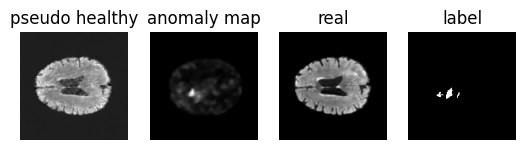

In [42]:
fig, axs = plt.subplots(1, 4)
sliceloc = 90
axs[0].imshow(pseudo_healthy.cpu()[sliceloc,0, :,:], cmap='gray')
axs[0].set_title('pseudo healthy')
axs[1].imshow(mask_median[0,:,:,sliceloc], cmap='gray')
axs[1].set_title('anomaly map')
axs[2].imshow(my_tensor.cpu()[sliceloc,0, :,:], cmap='gray')
axs[2].set_title('real')
axs[3].imshow(all_labels[0].cpu()[0,:,:,sliceloc], cmap='gray')
axs[3].set_title('label')
# remove axis
for ax in axs:
    ax.axis('off')
plt.show()


In [43]:
pseudo_healthy, my_tensor, mask_median, all_labels[0]

(tensor[155, 4, 128, 128] n=10158080 x∈[-1.348, 2.866] μ=-0.766 σ=0.365 cuda:0,
 tensor[155, 4, 128, 128] n=10158080 x∈[-1.000, 2.954] μ=-0.834 σ=0.397 cuda:0,
 tensor[2, 128, 128, 155] n=5079040 x∈[0., 1.000] μ=0.009 σ=0.031,
 tensor[1, 128, 128, 155] bool n=2539520 x∈[False, True] μ=0.006 σ=0.080)

In [44]:
# aggregating all results for this config
key = 'AnoDDPM-Brats'
real_slices[key] = all_images
real_segmentations[key] = all_labels
channelwise_maps[key] = all_volumes
anomaly_map[key] = mask_median
yen_threshold[key] = big_segmentation



In [45]:
torch.manual_seed(73)

args = ShiftsArgs()
args.model = 'AnoDDPM'

kwargs = DistributedDataParallelKwargs(find_unused_parameters=True)
accelerator = Accelerator(kwargs_handlers=[kwargs])
device = accelerator.device
model = UNet().to(device)
print(f"loading {args.model}")
ckpt = torch.load(f"/home/ubuntu/slurm_work/repos/normative-diffusion/models/Brats128_simplex/328_ema_ckpt.pt")
model.load_state_dict(ckpt)
diffusion = Diffusion(noise_steps=1000, img_size=128, device=device)
print("Loading dataset {}...".format(args.dataset_path))
dataloader = MRI_Volume(
    args, hist=False, shift=(True if "shifts" in args.dataset_path else False))

model, dataloader = accelerator.prepare(model, dataloader)
pbar = tqdm(dataloader)


all_images = []
all_volumes = []
all_labels = []


for i, (image, label) in enumerate(pbar):
    image = (image * 2) - 1
    num_steps = 250
    size_splits = 200
    num_volumes = image.shape[0]
    num_slices = image.shape[4]

    all_images.append(image.to("cpu"))
    image = torch.permute(image, (0, 4, 1, 2, 3))
    image = image.view(-1, image.shape[2], image.shape[3], image.shape[4])
    split = torch.split(image, size_splits)
    prediction = []
    with torch.no_grad():
        for my_tensor in split:
            pseudo_healthy = diffusion.ano_ddpm(model, my_tensor, num_steps,simplex=True)
            # break
            residual = (my_tensor - pseudo_healthy)**2
            prediction.append(residual)

    prediction = torch.cat(prediction, dim=0)
    prediction = prediction.view(
        num_volumes,
        num_slices,
        prediction.shape[1],
        prediction.shape[2],
        prediction.shape[3],
    )
    prediction = torch.permute(prediction, (0, 2, 3, 4, 1))
    prediction = prediction.to(device)
    prediction, label = accelerator.gather_for_metrics((prediction, label))
    all_labels.append(label.to("cpu"))
    all_volumes.append(prediction.to("cpu"))

all_volumes = torch.cat(all_volumes, dim=0)
my_labels = torch.cat(all_labels, dim=0)
all_images = torch.cat(all_images, dim=0)


loading AnoDDPM
Loading dataset data/shifts_registered/patients...


249it [03:46,  1.10it/s]:00<?, ?it/s]
249it [03:46,  1.10it/s]:54<03:54, 234.00s/it]
100%|██████████| 2/2 [07:41<00:00, 230.65s/it]


In [46]:

# anomaly map postprocessing
my_mask = torch.max(all_volumes, dim=1)[0]
mask_median = torch.clone(my_mask)
mask_median = median_filter_3D(mask_median, kernelsize=5)
mask_median = norm_tensor(mask_median)
my_mask = norm_tensor(my_mask)
big_segmentation = torch.zeros_like(my_mask)

# yen thresholding
for j, volume in enumerate(mask_median):
    thr = threshold_yen(volume.numpy())
    segmentation = torch.where(volume > thr, 1.0, 0.0)
    big_segmentation[j] = segmentation
            
struc = generate_binary_structure(3, 1)
big_segmentation = bin_dilation(big_segmentation, struc) # iterates inside over list of volumes

# compute dice yen
yen_val = []
yen_val.extend([float(x) for x in dice(big_segmentation, my_labels)])
yen_val = np.mean(np.asarray(yen_val))
print('yen dice score mf: ', yen_val)

# yen thresholding
for j, volume in enumerate(my_mask):
    thr = threshold_yen(volume.numpy())
    segmentation = torch.where(volume > thr, 1.0, 0.0)
    big_segmentation[j] = segmentation
            
struc = generate_binary_structure(3, 1)
big_segmentation = bin_dilation(big_segmentation, struc) # iterates inside over list of volumes

# compute dice yen
yen_val = []
yen_val.extend([float(x) for x in dice(big_segmentation, my_labels)])
yen_val = np.mean(np.asarray(yen_val))
print('yen dice score: ', yen_val)


Median filtering:   0%|          | 0/2 [00:00<?, ?it/s]

Binray Dilation: 100%|██████████| 2/2 [00:00<00:00, 22.57it/s]


yen dice score mf:  0.3972499817609787


Binray Dilation: 100%|██████████| 2/2 [00:00<00:00, 22.77it/s]

yen dice score:  0.0721471719443798


In [47]:
# aggregating all results for this config
key = 'AnoDDPM-Shifts'
real_slices[key] = all_images
real_segmentations[key] = all_labels
channelwise_maps[key] = all_volumes
anomaly_map[key] = mask_median
yen_threshold[key] = big_segmentation



In [195]:
real_slices['AnoDDPM-BraTS'] = real_slices['AnoDDPM-Brats']
real_segmentations['AnoDDPM-BraTS'] = real_segmentations['AnoDDPM-Brats']
channelwise_maps['AnoDDPM-BraTS'] = channelwise_maps['AnoDDPM-Brats']
anomaly_map['AnoDDPM-BraTS'] = anomaly_map['AnoDDPM-Brats']
yen_threshold['AnoDDPM-BraTS'] = yen_threshold['AnoDDPM-Brats']

real_slices['AnoDDPM-BraTS'] = real_slices['AnoDDPM-Brats']
real_segmentations['AnoDDPM-BraTS'] = real_segmentations['AnoDDPM-Brats']
channelwise_maps['AnoDDPM-BraTS'] = channelwise_maps['AnoDDPM-Brats']
anomaly_map['AnoDDPM-BraTS'] = anomaly_map['AnoDDPM-Brats']
yen_threshold['AnoDDPM-BraTS'] = yen_threshold['AnoDDPM-Brats']

In [106]:
real_slices.keys()

dict_keys(['ANDi_G_G-BraTS', 'ANDi_P_G-BraTS', 'ANDi_G_G-Shifts', 'ANDi_P_G-Shifts', 'AnoDDPM-Brats', 'AnoDDPM-Shifts', 'AutoDDPM-BraTS', 'AutoDDPM-Shifts', 'DAE-BraTS', 'DAE-Shifts', 'AnoDDPM-BraTS'])

# plotting

In [202]:
import matplotlib.pyplot as plt
import numpy as np
import torch  # Assuming your data is in PyTorch tensors

# Load your data here
# Replace these lines with the code to load your actual data
# Example: data = torch.load('path_to_your_data_file.pt')
data = {'real_slices': real_slices,
        'real_segmentations': real_segmentations,
        'channelwise_maps': channelwise_maps,
        'anomaly_map': anomaly_map,
        'yen_threshold': yen_threshold,
        }  # Your data dictionary

# # Setting up the plot
# methods = ['ANDi_G_G', 'ANDi_P_G', 'AnoDDPM', 'AutoDDPM', 'DAE']
# types = ['BraTS', 'Shifts']
# slice_index = 80  # The slice number you want to plot

# rows = 4  # 2 volumes each for Brats and Shifts
# cols = 5 + 2 * len(methods)  # Real slices (merged 4 channels), real segmentations, 2 columns per method
# fig, axes = plt.subplots(rows, cols, figsize=(cols * 2, rows * 2))

# for row in range(rows):
#     for col in range(cols):
#         # Determining the key based on row and column
#         volume_type = types[row // 2]
#         method = methods[(col - 5) // 2]
#         key = f'{method}-{volume_type}' if method else volume_type
#         print(row, col, key)


#         # Extracting and plotting the data
#         if col == 0:  # Merged real slices
#             real_slices = [process_slice(data['real_slices'][key][row][i], slice_index) for i in range(4)]
#             merged_slices = np.concatenate(real_slices, axis=1)  # Merging along the width
#             axes[row, col].imshow(merged_slices.T, cmap='gray')  # Transposing for correct orientation
#         elif col == 1:  # Real segmentations
#             segmentations = process_slice(data['real_segmentations'][key][row], slice_index)
#             axes[row, col].imshow(segmentations.T, cmap='gray')  # Transposing
#         elif col >= 5:  # Anomaly map and yen threshold
#             data_type = 'anomaly_map' if col % 2 == 0 else 'yen_threshold'
#             plot_data = process_slice(data[data_type][key][row], slice_index)
#             axes[row, col].imshow(plot_data.T, cmap='gray')  # Transposing

#         axes[row, col].axis('off')

# # Adjusting subplot spacing and aesthetics
# plt.subplots_adjust(wspace=0, hspace=0)
# plt.tight_layout()

# # Save the plot as a high-resolution image
# plt.savefig('plots/brain_slices_grid.pdf', dpi=300)

# # Show the plot
# plt.show()


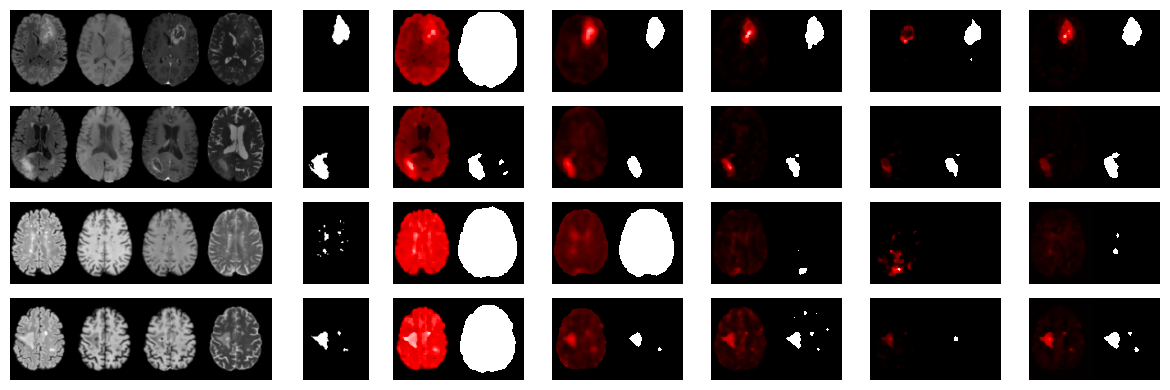

In [225]:
import matplotlib.gridspec as gridspec

# Setting up the figure
fig = plt.figure(figsize=(12, 4))  # Adjust the overall size of the figure as needed

# Define the widths of the columns in the GridSpec
# 'AAA' occupies 3 units, 'B' through 'L' occupy 1 unit each
# widths = [3, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
widths = [4, 1, 2, 2, 2, 2, 2]

# Creating a GridSpec with 4 rows and widths as defined
gs = gridspec.GridSpec(4, len(widths), width_ratios=widths, figure=fig)

# Creating an array to store the axes for easy indexing
axes_array = np.empty((4, len(widths)), dtype=object)

# Populating the axes array with subplots
for row in range(4):
    for col in range(len(widths)):
        axes_array[row, col] = fig.add_subplot(gs[row, col])


# Function to process and extract the required slice
def process_slice(data, slice_index):
    # Extracting the slice and converting it to numpy if it's a tensor
    if isinstance(data, torch.Tensor):
        return data[28:108, 18:118, slice_index].numpy()
    else:
        return data[28:108, 18:118, slice_index]


slice_index = [80, 80,  99, 107]
# creating real images
real_images = []
for i in range(4):
    slices = [process_slice((data['real_slices']['AnoDDPM-BraTS'][i][j] if (i < 2) else data['real_slices']['AnoDDPM-Shifts'][i-2][j]), slice_index[i]).T for j in range(4)]
    merged_slices = np.concatenate(slices, axis=1)
    real_images.append(merged_slices)

# creating real segmentations
real_segmentations_ = []
for i in range(4):
    segmentations = process_slice((data['real_segmentations']['AnoDDPM-BraTS'][i][0] if (i < 2) else data['real_segmentations']['AnoDDPM-Shifts'][i-2][0]), slice_index[i]).T
    segmentations = np.where(segmentations > 0, 1.0, 0.0)
    real_segmentations_.append(segmentations)

# plotting real images
for row in range(4):
    axes_array[row, 0].imshow(real_images[row], cmap='gray')
    axes_array[row, 0].axis('off')

# plotting real segmentations
for row in range(4):
    axes_array[row, 1].imshow(real_segmentations_[row], cmap='gray')
    axes_array[row, 1].axis('off')

methods = ['ANDi_P_G', 'AutoDDPM', 'AnoDDPM', 'DAE', 'Thresholding'][::-1]
for i_met, method in enumerate(methods):
    # creating anomaly maps
    anomaly_maps = []
    for i in range(4):
        data_to_choose = data['anomaly_map'][f'{method}-BraTS'][i] if (i < 2) else data['anomaly_map'][f'{method}-Shifts'][i-2]
        anomaly_map_ = process_slice(data_to_choose, slice_index[i]).T
        anomaly_maps.append(anomaly_map_)

    # creating yen thresholds
    yen_thresholds = []
    for i in range(4):
        data_to_choose = data['yen_threshold'][f'{method}-BraTS'][i] if (i < 2) else data['yen_threshold'][f'{method}-Shifts'][i-2]
        yen_threshold_ = process_slice(data_to_choose, slice_index[i]).T
        yen_thresholds.append(yen_threshold_)

    # plotting anomaly maps
    for row in range(4):
        merged_ano = np.concatenate([anomaly_maps[row], yen_thresholds[row]], axis=1)
        axes_array[row, 2+i_met].imshow(merged_ano, cmap=custom_cmap, interpolation='none')
        axes_array[row, 2+i_met].axis('off')

fig.tight_layout()
plt.savefig('plots/brain_slices_grid_color.pdf', dpi=300)


In [115]:
yen_threshold

{'ANDi_G_G-BraTS': tensor[2, 128, 128, 155] n=5079040 x∈[0., 1.000] μ=0.005 σ=0.069,
 'ANDi_P_G-BraTS': tensor[2, 128, 128, 155] n=5079040 x∈[0., 1.000] μ=0.006 σ=0.079,
 'ANDi_G_G-Shifts': tensor[2, 128, 128, 155] n=5079040 x∈[0., 1.000] μ=0.001 σ=0.026,
 'ANDi_P_G-Shifts': tensor[2, 128, 128, 155] n=5079040 x∈[0., 1.000] μ=0.002 σ=0.049,
 'AnoDDPM-Brats': tensor[2, 128, 128, 155] n=5079040 x∈[0., 1.000] μ=0.004 σ=0.062,
 'AnoDDPM-Shifts': tensor[2, 128, 128, 155] n=5079040 x∈[0., 1.000] μ=0.000 σ=0.021,
 'AutoDDPM-BraTS': tensor[2, 128, 128, 155] n=5079040 x∈[0., 1.000] μ=0.004 σ=0.065,
 'AutoDDPM-Shifts': tensor[2, 128, 128, 155] n=5079040 x∈[0., 1.000] μ=0.000 σ=0.019,
 'DAE-BraTS': tensor[2, 128, 128, 155] n=5079040 x∈[0., 1.000] μ=0.029 σ=0.167,
 'DAE-Shifts': tensor[2, 128, 128, 155] n=5079040 x∈[0., 1.000] μ=0.110 σ=0.313,
 'AnoDDPM-BraTS': tensor[2, 128, 128, 155] n=5079040 x∈[0., 1.000] μ=0.004 σ=0.062}

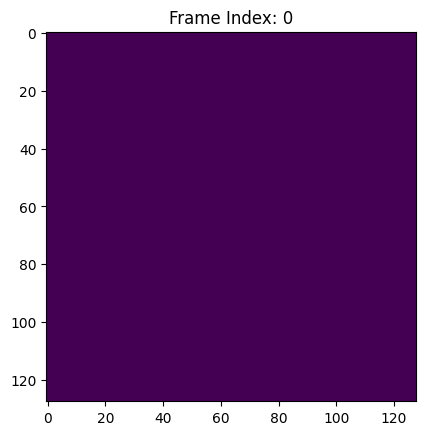

In [160]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import numpy as np

# create a sample tensor with shape (128, 128, 155)
tensor = data['real_segmentations']['AnoDDPM-Shifts'][1][0]

# initialize the plot
fig, ax = plt.subplots()

# function to update the frame
def update_frame(frame_index):
    ax.clear()
    ax.imshow(tensor[:, :, frame_index])
    ax.set_title(f"Frame Index: {frame_index}")

# create the animation and return the object
ani = animation.FuncAnimation(fig, update_frame, frames=155, interval=50)

# Return the animation object
ani.save('plots/sample_animation.mp4', writer='imagemagick', fps=30)

from IPython.display import Video
Video("plots/sample_animation.mp4")

In [224]:
from matplotlib.colors import LinearSegmentedColormap

# defining the colormap
# black (0, 0, 0) -> red (1, 0, 0) -> white (1, 1, 1)
# cmap_data = {'red':   [(0.0, 0.0, 0.0),
#                        (0.5, 1.0, 1.0),
#                        (1.0, 1.0, 1.0)],
#              'green': [(0.0, 0.0, 0.0),
#                        (0.5, 0.0, 0.0),
#                        (1.0, 1.0, 1.0)],
#              'blue':  [(0.0, 0.0, 0.0),
#                        (0.5, 0.0, 0.0),
#                        (1.0, 1.0, 1.0)]}

# custom_cmap = LinearSegmentedColormap('BlackRedWhite', cmap_data)
cmap_data = {'red':   [(0.0, 0.0, 0.0),
                                  (0.75, 1.0, 1.0),
                                  (1.0, 1.0, 1.0)],
                        'green': [(0.0, 0.0, 0.0),
                                  (0.75, 0.0, 0.0),
                                  (1.0, 1.0, 1.0)],
                        'blue':  [(0.0, 0.0, 0.0),
                                  (0.75, 0.0, 0.0),
                                  (1.0, 1.0, 1.0)]}

custom_cmap = LinearSegmentedColormap('BlackRedWhiteTonedDown', cmap_data)
